In [1]:
from helpers.ml import (get_training_logger, 
                        train_models_for_target, 
                        cluster_and_split,
                        LogTransformer)
from helpers.preprocessors import load_dict_from_file
from helpers.plotters import plot_observed_vs_predicted

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS  # For distinct colors

from sklearn.model_selection import (
    GroupShuffleSplit, 
    train_test_split
)
from sklearn.linear_model import BayesianRidge, ElasticNet
from sklearn.svm import SVR
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

import random
import os
import joblib

In [2]:
SSL_FOLDER = 'doukkala_ssl_datasets'
# List all CSV files in the 'doukkala_ssl_datasets' directory
csv_files = [f for f in os.listdir(SSL_FOLDER) if f.endswith('.csv')]
print(csv_files)

['merged_doukkala_absorbance.csv', 'merged_doukkala_raw_spectra.csv', 'merged_doukkala_smoothed_spectra.csv', 'merged_doukkala_first_derivative.csv']


In [3]:
merged_dataset = pd.read_csv(os.path.join(SSL_FOLDER, csv_files[0]))

In [4]:
# ---------------------------
# Constants and Settings
# ---------------------------
RANDOM_SEED = random.randint(0, 1000000)
ENABLE_HYPERPARAMETER_TUNING = False
USE_BAYES_OPT = True
USE_RFE = False
USE_GROUP_SPLIT = False  # Set to False for simple train-test split
TEST_SIZE = 0.2
SPLIT_STRATEGY = 'kfold' # 'kfold', 'groupkfold' or 'stratifiedshuffle'

columns_to_transform = ['Clay%', 'Coarse element %', 'C.E.C (meq / 100g)', 'Na2O ppm', 'Cl- ppm', 
                        'Organic matter%', 'Exchangeable K2O ppm', 'P2O5 ehangable Olsen ppm',
                        'MgO ppm', 'Iron ppm DTPA', 'Mn ppm DTPA']

os.makedirs("final_models", exist_ok=True)
os.makedirs("metrics", exist_ok=True)

In [5]:
# ---------------------------
# Model Pipelines Configuration
# ---------------------------

num_features = 50

model_pipelines = {
    "PLSRegression": {
        "model": PLSRegression(),
        "params": {
            "model__n_components": np.arange(2, min(21, num_features + 1), 2)
        }
    },
    "ElasticNet": {
        "model": ElasticNet(max_iter=10000),
        "params": {
            "model__alpha": np.logspace(-4, 0.5, 8),
            "model__l1_ratio": np.concatenate([
                np.linspace(0.1, 0.5, 3),
                np.linspace(0.6, 1.0, 5)
            ])
        }
    },
    "BayesianRidge": {
        "model": BayesianRidge(),
        "params": {
            "model__alpha_1": np.logspace(-6, -2, 5),
            "model__alpha_2": np.logspace(-6, -2, 5),
            "model__lambda_1": np.logspace(-6, -2, 5),
            "model__lambda_2": np.logspace(-6, -2, 5)
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            "model__kernel": ["rbf", "linear"],
            "model__C": np.logspace(-2, 2, 6),
            "model__gamma": ["scale", "auto"],
            "model__epsilon": [0.01, 0.1, 0.2]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=RANDOM_SEED),
        "params": {
            "model__n_estimators": list(range(100, 351, 50)),
            "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "model__max_depth": list(range(3, 20, 2)),
            "model__subsample": [0.6, 0.8, 1.0],
            "model__min_samples_split": [2, 5, 10]
        }
    }
}

In [6]:
# ---------------------------
# Logging Configuration
# ---------------------------
logger = get_training_logger(name='AlMoutmir Soil Models Training', log_file='metrics/model_training.log')
logger.info("Logger initialized successfully.")

# ---------------------------
# Define Columns and Model Pipelines
# ---------------------------
target_columns = ['Sand%', 
                  'Clay%', 
                  'Total_Silt%', 
                  'pH_water', 
                  'CE_ext1 / 5 ms / cm',
                  'C / N ratio', 
                  'Organic matter%', 
                  'Exchangeable K2O ppm', 
                  'P2O5 ehangable Olsen ppm'
                  ]

eliminated = ['uuid', 'Latitude_Y', 'Longitude_X', 'Month', 'Fine silt%', 'Coarse silt%', 'CaCo3%_Total', 'CaO ppm', 
              'Coarse element %', 'CaCo3 active%', 'C.E.C (meq / 100g)', 'Na2O ppm', 'Cl- ppm', 
              'Na meq / 100g', 'MgO ppm', 'Iron ppm DTPA', 'Mn ppm DTPA', 'Cu ppm DTPA', 'Zn ppm DTPA', 'B ppm Hot water',
              #'Elevation', 'GPP', 'ET', 'LST', 'NDVI', 'SU_WRB1_PH', 
              'Slope', 
              #'bio01', 'bio02', 'bio03', 'bio04', 'bio05', 'bio06', 'bio07', 'bio08', 'bio09', 'bio10', 
              #'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19'
              ]
feature_columns = [col for col in merged_dataset.columns if col not in target_columns + eliminated]
#feature_columns = [col for col in merged_dataset.columns if col in eliminated]

# ---------------------------
# KMeans Clustering for Spatial Segmentation
# ---------------------------

logger.info("Clustering dataset based on spatial location (KMeans)...")
merged_df = cluster_and_split(merged_dataset, seed=RANDOM_SEED)
logger.info(f"Cluster value counts:\n{merged_df['cluster'].value_counts().to_string()}")

# ---------------------------
# Dataset Splitting
# ---------------------------

# Drop only columns in X that are all NaNs, and drop rows with any NaNs in X
valid_feature_columns = merged_df[feature_columns].dropna(axis=1, how='all').columns.tolist()
X_base = merged_df[valid_feature_columns]

# One-hot encode only the 'SU_WRB1_PH' column
if 'SU_WRB1_PH' in X_base.columns:
    logger.info("One-hot encoding 'SU_WRB1_PH' column...")
    # One-hot encode the 'SU_WRB1_PH' column
    X_base = pd.get_dummies(X_base, columns=['SU_WRB1_PH'])


X_base = X_base.apply(lambda row: row.fillna(row.mean()), axis=1)
merged_cleaned = merged_df.loc[X_base.index]

groups_all = merged_cleaned['cluster']
y_all = merged_cleaned[target_columns]

if USE_GROUP_SPLIT:
    logger.info("Splitting dataset into train and test groups using GroupShuffleSplit...")
    
    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)
    train_idx, test_idx = next(gss.split(X_base, y_all, groups=groups_all))
    
    X_train_all, X_test_all = X_base.iloc[train_idx], X_base.iloc[test_idx]
    y_train_all, y_test_all = y_all.iloc[train_idx], y_all.iloc[test_idx]
    groups_train_all = groups_all.iloc[train_idx]
    groups_test_all = groups_all.iloc[test_idx]
    
    logger.info("Splitting dataset into train/test groups using GroupShuffleSplit... "
                f"Train: {len(train_idx)} rows | Test: {len(test_idx)} rows")
    
    logger.info(f"Train group distribution:\n{groups_train_all.value_counts().sort_index().to_string()}")
    logger.info(f"Test group distribution:\n{groups_test_all.value_counts().sort_index().to_string()}")
    logger.info(f"Test set includes groups: {sorted(groups_test_all.unique())}")
else:
    logger.info("Splitting dataset using simple train-test split...")
    
    X_train_all, X_test_all, y_train_all, y_test_all, groups_train_all, groups_test_all = train_test_split(
        X_base, y_all, groups_all, test_size=TEST_SIZE, random_state=RANDOM_SEED
    )
    
    logger.info("Splitting dataset using simple train-test split... "
                f"Train: {len(X_train_all)} rows | Test: {len(X_test_all)} rows")
    
    logger.info(f"Train group distribution:\n{groups_train_all.value_counts().sort_index().to_string()}")
    logger.info(f"Test group distribution:\n{groups_test_all.value_counts().sort_index().to_string()}")



2025-05-15 14:40:03,130 - AlMoutmir Soil Models Training - INFO - Logger initialized successfully.
2025-05-15 14:40:03,131 - AlMoutmir Soil Models Training - INFO - Clustering dataset based on spatial location (KMeans)...


[INFO] Starting KMeans clustering for spatial segmentation.
[INFO] Clustering completed successfully.


2025-05-15 14:40:03,293 - AlMoutmir Soil Models Training - INFO - Cluster value counts:
cluster
7.0     152
2.0     144
8.0     142
12.0    132
11.0    106
1.0     106
6.0     104
4.0      82
9.0      70
3.0      70
5.0      57
10.0     54
2025-05-15 14:40:03,301 - AlMoutmir Soil Models Training - INFO - One-hot encoding 'SU_WRB1_PH' column...
2025-05-15 14:40:03,570 - AlMoutmir Soil Models Training - INFO - Splitting dataset using simple train-test split...
2025-05-15 14:40:03,580 - AlMoutmir Soil Models Training - INFO - Splitting dataset using simple train-test split... Train: 975 rows | Test: 244 rows
2025-05-15 14:40:03,582 - AlMoutmir Soil Models Training - INFO - Train group distribution:
cluster
1.0      81
2.0     113
3.0      59
4.0      68
5.0      45
6.0      81
7.0     120
8.0     113
9.0      58
10.0     37
11.0     85
12.0    115
2025-05-15 14:40:03,583 - AlMoutmir Soil Models Training - INFO - Test group distribution:
cluster
1.0     25
2.0     31
3.0     11
4.0     14


In [7]:
feature_columns

['ET',
 'Elevation',
 'GPP',
 'LST',
 'NDVI',
 'SU_WRB1_PH',
 'bio01',
 'bio02',
 'bio03',
 'bio04',
 'bio05',
 'bio06',
 'bio07',
 'bio08',
 'bio09',
 'bio10',
 'bio11',
 'bio12',
 'bio13',
 'bio14',
 'bio15',
 'bio16',
 'bio17',
 'bio18',
 'bio19',
 'Band_1',
 'Band_2',
 'Band_3',
 'Band_4',
 'Band_5',
 'Band_6',
 'Band_7',
 'Band_8',
 'Band_9',
 'Band_10',
 'Band_11',
 'Band_12',
 'Band_13',
 'Band_14',
 'Band_15',
 'Band_16',
 'Band_17',
 'Band_18',
 'Band_19',
 'Band_20',
 'Band_21',
 'Band_22',
 'Band_23',
 'Band_24',
 'Band_25',
 'Band_26',
 'Band_27',
 'Band_28',
 'Band_29',
 'Band_30',
 'Band_31',
 'Band_32',
 'Band_33',
 'Band_34',
 'Band_35',
 'Band_36',
 'Band_37',
 'Band_38',
 'Band_39',
 'Band_40',
 'Band_41',
 'Band_42',
 'Band_43',
 'Band_44',
 'Band_45',
 'Band_46',
 'Band_47',
 'Band_48',
 'Band_49',
 'Band_50',
 'Band_51',
 'Band_52',
 'Band_53',
 'Band_54',
 'Band_55',
 'Band_56',
 'Band_57',
 'Band_58',
 'Band_59',
 'Band_60',
 'Band_61',
 'Band_62',
 'Band_63',
 '

In [8]:
# ---------------------------
# Run Training for All Targets
# ---------------------------
logger.info("Starting full training process for all targets...")
all_results = []
for target in target_columns:
    res = train_models_for_target(
            target=target,
            X_train=X_train_all,
            y_train=y_train_all[target],
            X_test=X_test_all,
            y_test=y_test_all[target],
            groups_train=groups_train_all,
            model_pipelines=model_pipelines,
            columns_to_transform=columns_to_transform,
            seed=RANDOM_SEED,
            split_strategy=SPLIT_STRATEGY,
            enable_hyperparameter_tuning=ENABLE_HYPERPARAMETER_TUNING, 
            use_bayes_opt=USE_BAYES_OPT,
            enable_rfe= USE_RFE
        )
    if res:
        all_results.extend(res)

# ---------------------------
# Save and Display Final Metrics
# ---------------------------
metrics_df = pd.DataFrame(all_results)
top_models = metrics_df.groupby("target").apply(lambda df: df.sort_values("Test_R2", ascending=False).head(1))
top_models.to_csv("metrics/best_models_summary.csv", index=False)
metrics_df.to_csv("metrics/all_models_metrics.csv", index=False)
logger.info("Metrics saved to metrics/all_models_metrics.csv")
print("\nFinal Metrics DataFrame:")

joblib.dump({
    "X_test": X_test_all,
    "y_test": y_test_all
}, "final_models/test_sets.pkl")
logger.info("Test sets saved to final_models/test_sets.pkl")

# Display the metrics DataFrame
display(metrics_df)

2025-05-15 14:40:20,682 - AlMoutmir Soil Models Training - INFO - Starting full training process for all targets...


[INFO] Training for target: Sand% — 791 train samples, 202 test samples.
[INFO] Training PLSRegression for Sand%
[INFO] Skipping RFE for PLSRegression.
[INFO] Fold 1 — Validation size: 159 samples
[INFO] Fold 2 — Validation size: 158 samples
[INFO] Fold 3 — Validation size: 158 samples
[INFO] Fold 4 — Validation size: 158 samples
[INFO] Fold 5 — Validation size: 158 samples
[INFO] 🏁 PLSRegression | Sand% — CV RMSE: 20.6075, Test RMSE: 19.5558, R²: 0.2312
[INFO] Saved model to final_models/Sand%_PLSRegression.pkl and metrics to metrics/Sand%_PLSRegression_metrics.csv
[INFO] Training ElasticNet for Sand%
[INFO] Fold 1 — Validation size: 159 samples
[INFO] Fold 2 — Validation size: 158 samples
[INFO] Fold 3 — Validation size: 158 samples
[INFO] Fold 4 — Validation size: 158 samples
[INFO] Fold 5 — Validation size: 158 samples
[INFO] 🏁 ElasticNet | Sand% — CV RMSE: 20.2124, Test RMSE: 19.2652, R²: 0.2538
[INFO] Saved model to final_models/Sand%_ElasticNet.pkl and metrics to metrics/Sand%_E

2025-05-15 14:42:48,999 - AlMoutmir Soil Models Training - INFO - Metrics saved to metrics/all_models_metrics.csv

Final Metrics DataFrame:
2025-05-15 14:42:49,013 - AlMoutmir Soil Models Training - INFO - Test sets saved to final_models/test_sets.pkl


/var/folders/sn/9st0f2sx45v3qxbzgrntvpgr0000gn/T/ipykernel_29704/2607701523.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_models = metrics_df.groupby("target").apply(lambda df: df.sort_values("Test_R2", ascending=False).head(1))


,target,model,Test_RMSE,Test_MAE,Test_R2,CV_RMSE_Mean,CV_RMSE_Std,Test_ExplainedVar,Best_Params
0,Sand%,PLSRegression,19.555775,16.049334,0.231159,20.607464,1.622636,2.343549e-01,Default (no tuning)
1,Sand%,ElasticNet,19.265201,15.734393,0.253837,20.212364,1.520925,2.574590e-01,Default (no tuning)
2,Sand%,BayesianRidge,18.902443,15.277151,0.281673,19.262011,1.152152,2.897978e-01,Default (no tuning)
3,Sand%,SVR,20.105907,16.258052,0.187294,20.710569,1.503648,1.902351e-01,Default (no tuning)
4,Sand%,GradientBoosting,14.055305,11.002823,0.602839,13.812220,1.190010,6.064724e-01,Default (no tuning)
5,Clay%,PLSRegression,20.638199,14.745246,0.100321,7.198710,0.508274,1.780379e-01,Default (no tuning)
6,Clay%,ElasticNet,20.910512,14.411066,0.076423,7.195801,0.504059,1.848867e-01,Default (no tuning)
7,Clay%,BayesianRidge,19.465745,13.770416,0.199639,6.710872,0.443886,2.717709e-01,Default (no tuning)
8,Clay%,SVR,19.498845,13.502209,0.196915,7.011258,0.500198,2.510407e-01,Default (no tuning)
9,Clay%,GradientBoosting,15.976760,11.018851,0.460836,5.160670,0.514910,4.825384e-01,Default (no tuning)


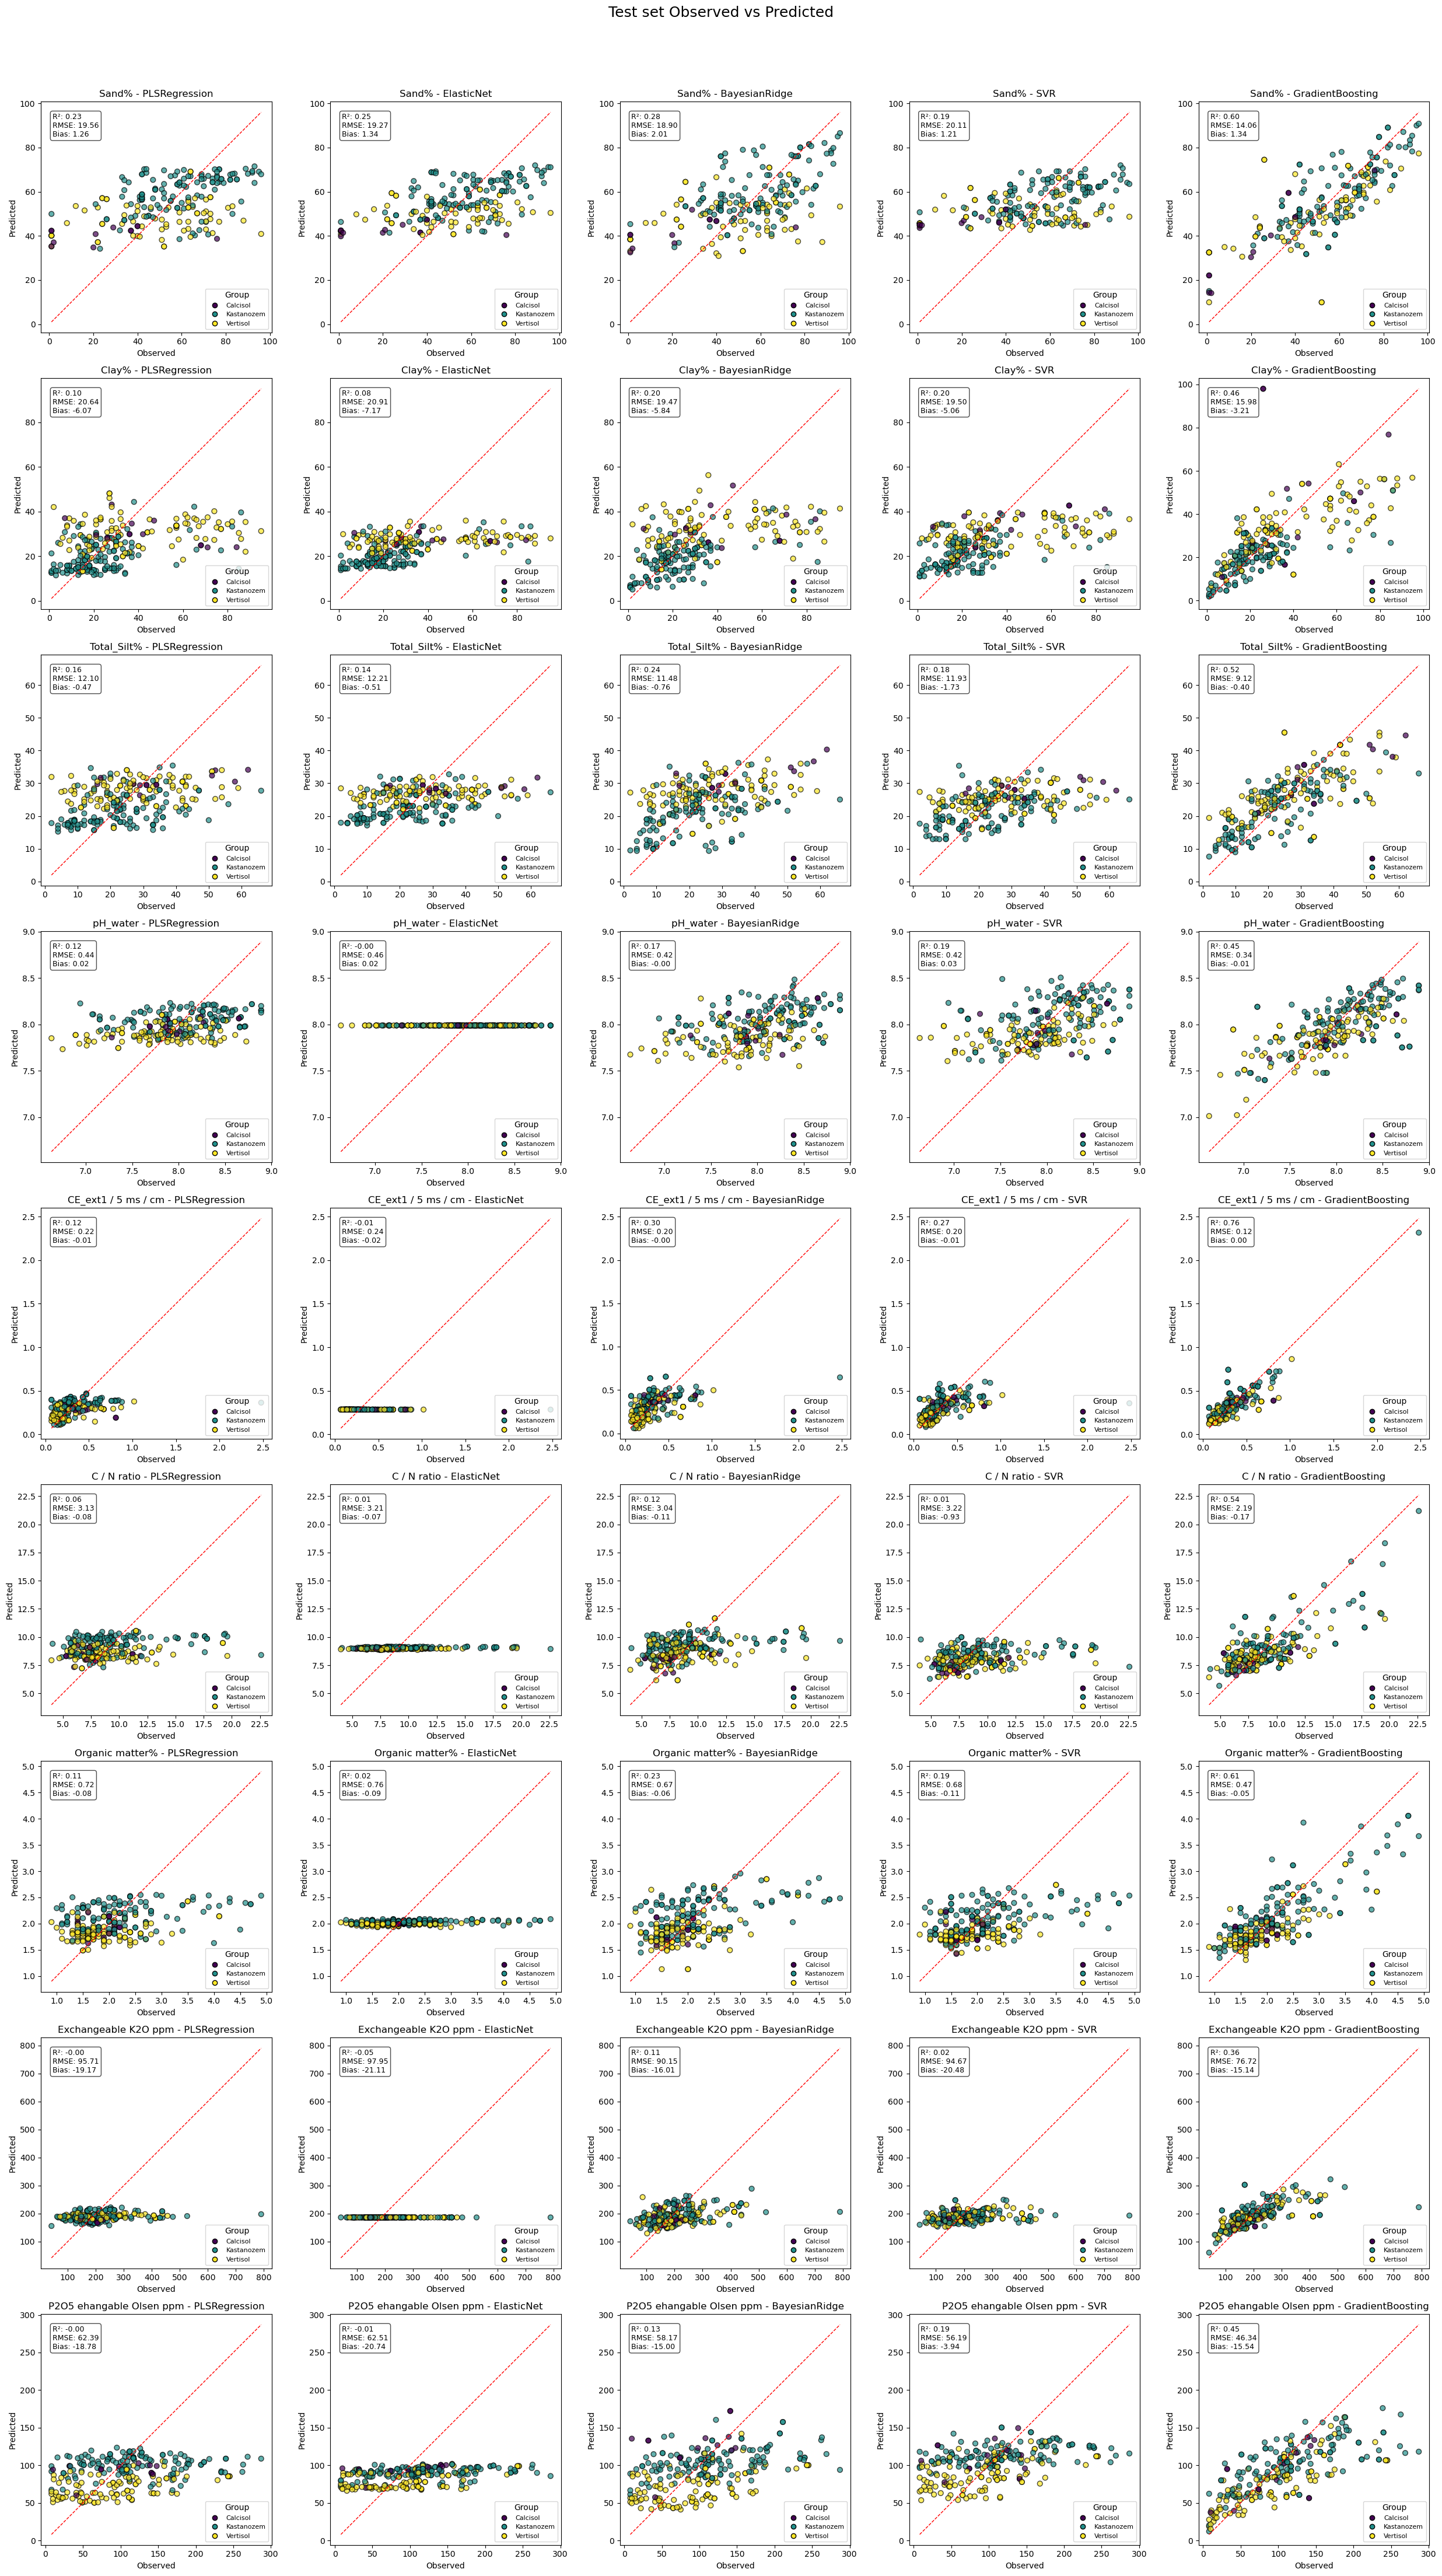

In [9]:
# Load Soil Groups:
file_path = "soil_groups.txt"
dictionary = load_dict_from_file(file_path)

# Optional: define group label mapping (fuzzy substring match)
group_prefix = "SU_WRB1_PH_"
group_label_map = load_dict_from_file(file_path)

# Load your data
test_sets = joblib.load("final_models/test_sets.pkl")
X_test = test_sets["X_test"]
y_test_dict = test_sets["y_test"]

# Run the plot
plot_observed_vs_predicted(
    X_test=X_test,
    y_test_dict=y_test_dict,
    model_pipelines=model_pipelines,
    target_columns=target_columns,
    columns_to_transform=columns_to_transform,
    log_transformer=LogTransformer(),
    group_prefix=group_prefix,
    group_label_map=group_label_map
)

In [ ]:
# Load test data
test_sets = joblib.load("final_models/test_sets.pkl")
X_test = test_sets["X_test"]
y_test_dict = test_sets["y_test"]

# Model directory and transformation setup
model_dir = "final_models"
log_transformer = LogTransformer()  # Ensure this is defined/imported
model_names = list(model_pipelines.keys())  # e.g., {"ridge": ..., "rf": ...}
n_targets = len(target_columns)
n_models = len(model_names)

# Set up plot grid
fig, axes = plt.subplots(n_targets, n_models, figsize=(5 * n_models, 5 * n_targets))
fig.suptitle("Test set Observed vs Predicted", fontsize=18)

# Ensure axes is always 2D
axes = np.atleast_2d(axes)

# Loop over targets and models
for i, target in enumerate(target_columns):
    y_test_full = y_test_dict[target]
    is_log = target in columns_to_transform

    for j, model_name in enumerate(model_names):
        ax = axes[i, j]
        model_file = os.path.join(model_dir, f"{target.replace('/', '_')}_{model_name}.pkl")

        if not os.path.exists(model_file):
            ax.set_title(f"{target} - {model_name} (Missing)")
            ax.axis("off")
            continue

        model = joblib.load(model_file)
        
        y_pred_raw = model.predict(X_test)

        # Convert to Series for safe alignment
        y_test = pd.Series(y_test_full, index=X_test.index)
        y_pred = pd.Series(y_pred_raw, index=X_test.index)

        # Inverse transform if needed
        if is_log:
            y_pred = log_transformer.inverse_transform(y_pred)

        # Filter out NaNs
        valid_mask = y_test.notna() & y_pred.notna()
        y_test_clean = y_test.loc[valid_mask]
        y_pred_clean = y_pred.loc[valid_mask]

        # Compute metrics
        r2 = r2_score(y_test_clean, y_pred_clean)
        rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
        bias = np.mean(y_pred_clean - y_test_clean)

        # Plot
        ax.scatter(y_test_clean, y_pred_clean, alpha=0.5)
        min_val = min(y_test_clean.min(), y_pred_clean.min())
        max_val = max(y_test_clean.max(), y_pred_clean.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1)
        ax.set_title(f"{target} - {model_name}")
        ax.set_xlabel("Observed")
        ax.set_ylabel("Predicted")
        ax.set_aspect('equal', 'box')

        # Annotate with metrics
        ax.text(0.05, 0.95,
                f"R²: {r2:.2f}\nRMSE: {rmse:.2f}\nBias: {bias:.2f}",
                transform=ax.transAxes,
                fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

# Final layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# Load test data
test_sets = joblib.load("final_models/test_sets.pkl")
X_test = test_sets["X_test"]
y_test_dict = test_sets["y_test"]

# Optional: Column in X_test to group/color by
group_col = "SU_WRB1_PH"  # Set to a column name (e.g., "region") to enable color grouping

# Model directory and transformation setup
model_dir = "final_models"
log_transformer = LogTransformer()  # Ensure this is defined/imported
model_names = list(model_pipelines.keys())  # e.g., {"ridge": ..., "rf": ...}
n_targets = len(target_columns)
n_models = len(model_names)

# Set up plot grid
fig, axes = plt.subplots(n_targets, n_models, figsize=(5 * n_models, 5 * n_targets))
fig.suptitle("Test set Observed vs Predicted", fontsize=18)

# Ensure axes is always 2D
axes = np.atleast_2d(axes)

# Loop over targets and models
for i, target in enumerate(target_columns):
    y_test_full = y_test_dict[target]
    is_log = target in columns_to_transform

    for j, model_name in enumerate(model_names):
        ax = axes[i, j]
        model_file = os.path.join(model_dir, f"{target.replace('/', '_')}_{model_name}.pkl")

        if not os.path.exists(model_file):
            ax.set_title(f"{target} - {model_name} (Missing)")
            ax.axis("off")
            continue

        model = joblib.load(model_file)
        y_pred_raw = model.predict(X_test)

        # Convert to Series for safe alignment
        y_test = pd.Series(y_test_full, index=X_test.index)
        y_pred = pd.Series(y_pred_raw, index=X_test.index)

        # Inverse transform if needed
        if is_log:
            y_pred = log_transformer.inverse_transform(y_pred)

        # Filter out NaNs
        valid_mask = y_test.notna() & y_pred.notna()
        y_test_clean = y_test.loc[valid_mask]
        y_pred_clean = y_pred.loc[valid_mask]

        # Compute metrics
        r2 = r2_score(y_test_clean, y_pred_clean)
        rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
        bias = np.mean(y_pred_clean - y_test_clean)

        # Plot
        if group_col is not None and group_col in X_test.columns:
            group_values = X_test.loc[valid_mask, group_col]
            scatter = ax.scatter(
                y_test_clean,
                y_pred_clean,
                c=group_values,
                cmap="viridis",
                alpha=0.6,
                edgecolor='k',
                s=40
            )
        else:
            scatter = ax.scatter(
                y_test_clean,
                y_pred_clean,
                alpha=0.5,
                edgecolor='k',
                s=40
            )

        min_val = min(y_test_clean.min(), y_pred_clean.min())
        max_val = max(y_test_clean.max(), y_pred_clean.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1)
        ax.set_title(f"{target} - {model_name}")
        ax.set_xlabel("Observed")
        ax.set_ylabel("Predicted")
        ax.set_aspect('equal', 'box')

        # Annotate with metrics
        ax.text(0.05, 0.95,
                f"R²: {r2:.2f}\nRMSE: {rmse:.2f}\nBias: {bias:.2f}",
                transform=ax.transAxes,
                fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

# Add a colorbar if group_col is used
if group_col is not None and group_col in X_test.columns:
    cbar = fig.colorbar(scatter, ax=axes.ravel().tolist(), shrink=0.95)
    cbar.set_label(group_col)

# Final layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# Define your transformers and model pipelines (make sure these are defined)
log_transformer = LogTransformer()  # Ensure this is defined/imported

# Find all trial folders
base_dir = "."  # or specify your base directory
trial_folders = [f for f in os.listdir(base_dir) 
                if os.path.isdir(os.path.join(base_dir, f)) 
                and f.startswith("Trial_")]

# Check for random_split folder
random_split_folder = "random_split" if os.path.exists(os.path.join(base_dir, "random_split")) else None

# Get colors for each trial
colors = list(TABLEAU_COLORS.values())[:len(trial_folders)]
trial_color_map = dict(zip(trial_folders, colors))

# Model names
model_names = list(model_pipelines.keys())
n_targets = len(target_columns)
n_models = len(model_names)

# Set up plot grid
fig, axes = plt.subplots(n_targets, n_models, figsize=(5 * n_models, 5 * n_targets))
fig.suptitle("Test set Observed vs Predicted (Multiple Trials vs Random Split)", fontsize=18)

# Ensure axes is always 2D
axes = np.atleast_2d(axes)

# Define style for random split
RANDOM_SPLIT_COLOR = '#444444'  # Dark grey
RANDOM_SPLIT_MARKER = 'X'       # Distinct marker
RANDOM_SPLIT_SIZE = 40          # Slightly larger
RANDOM_SPLIT_ALPHA = 0       # More opaque

# Define style for trials
TRIAL_ALPHA = 0.5               # More transparent
TRIAL_SIZE = 30                 # Standard size

# Loop over targets and models
for i, target in enumerate(target_columns):
    for j, model_name in enumerate(model_names):
        ax = axes[i, j]
        ax.set_title(f"{target} - {model_name}")
        ax.set_xlabel("Observed")
        ax.set_ylabel("Predicted")
        
        # Store metrics for all trials (excluding random_split)
        all_r2 = []
        all_rmse = []
        all_bias = []
        
        # Store all data points for this subplot to set equal limits
        all_y_test = []
        all_y_pred = []
        
        # First plot the trial data in background
        for trial in trial_folders:
            try:
                # Load test data for this trial
                test_sets = joblib.load(os.path.join(trial, "test_sets.pkl"))
                X_test = test_sets["X_test"]
                y_test_dict = test_sets["y_test"]
                y_test_full = y_test_dict[target]
                
                # Load model
                model_file = os.path.join(trial, f"{target.replace('/', '_')}_{model_name}.pkl")
                if not os.path.exists(model_file):
                    continue
                
                model = joblib.load(model_file)
                y_pred_raw = model.predict(X_test)
                
                # Convert to Series for safe alignment
                y_test = pd.Series(y_test_full, index=X_test.index)
                y_pred = pd.Series(y_pred_raw, index=X_test.index)
                
                # Inverse transform if needed
                is_log = target in columns_to_transform
                if is_log:
                    y_pred = log_transformer.inverse_transform(y_pred)
                
                # Filter out NaNs
                valid_mask = y_test.notna() & y_pred.notna()
                y_test_clean = y_test.loc[valid_mask]
                y_pred_clean = y_pred.loc[valid_mask]
                
                # Store data points
                all_y_test.extend(y_test_clean.values)
                all_y_pred.extend(y_pred_clean.values)
                
                # Compute metrics
                r2 = r2_score(y_test_clean, y_pred_clean)
                rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
                bias = np.mean(y_pred_clean - y_test_clean)
                
                # Store metrics
                all_r2.append(r2)
                all_rmse.append(rmse)
                all_bias.append(bias)
                
                # Plot trial data with reduced prominence
                ax.scatter(y_test_clean, y_pred_clean, 
                          alpha=TRIAL_ALPHA, s=TRIAL_SIZE,
                          color=trial_color_map[trial], 
                          label=trial)
                
            except Exception as e:
                print(f"Error processing {trial} for {target}-{model_name}: {str(e)}")
                continue
        
        # Then plot random_split data in foreground if it exists
        if random_split_folder:
            try:
                # Load test data for random_split
                test_sets = joblib.load(os.path.join(random_split_folder, "test_sets.pkl"))
                X_test = test_sets["X_test"]
                y_test_dict = test_sets["y_test"]
                y_test_full = y_test_dict[target]
                
                # Load model
                model_file = os.path.join(random_split_folder, f"{target.replace('/', '_')}_{model_name}.pkl")
                if os.path.exists(model_file):
                    model = joblib.load(model_file)
                    y_pred_raw = model.predict(X_test)
                    
                    # Convert to Series for safe alignment
                    y_test = pd.Series(y_test_full, index=X_test.index)
                    y_pred = pd.Series(y_pred_raw, index=X_test.index)
                    
                    # Inverse transform if needed
                    is_log = target in columns_to_transform
                    if is_log:
                        y_pred = log_transformer.inverse_transform(y_pred)
                    
                    # Filter out NaNs
                    valid_mask = y_test.notna() & y_pred.notna()
                    y_test_clean = y_test.loc[valid_mask]
                    y_pred_clean = y_pred.loc[valid_mask]
                    
                    # Plot random split with prominent style
                    ax.scatter(y_test_clean, y_pred_clean, 
                              alpha=RANDOM_SPLIT_ALPHA, s=RANDOM_SPLIT_SIZE,
                              color=RANDOM_SPLIT_COLOR, marker=RANDOM_SPLIT_MARKER,
                              label='Random split', zorder=3)  # zorder brings to front
                    
                    # Store for limits calculation but don't include in metrics
                    all_y_test.extend(y_test_clean.values)
                    all_y_pred.extend(y_pred_clean.values)
                    
            except Exception as e:
                print(f"Error processing random_split for {target}-{model_name}: {str(e)}")
        
        # Add reference line and set aspect ratio if we have any data
        if len(all_y_test) > 0:
            # Get overall min and max values
            min_val = min(all_y_test + all_y_pred)
            max_val = max(all_y_test + all_y_pred)
            
            # Add some padding to the limits
            padding = 0.05 * (max_val - min_val)
            ax.set_xlim(min_val - padding, max_val + padding)
            ax.set_ylim(min_val - padding, max_val + padding)
            
            # Set 1:1 aspect ratio
            ax.set_aspect('equal', 'box')
            
            # Add reference line
            ax.plot([min_val - padding, max_val + padding], 
                    [min_val - padding, max_val + padding], 
                    'r--', lw=1, zorder=2)
            
            # Calculate average metrics (only from main trials)
            if len(all_r2) > 0:
                avg_r2 = np.mean(all_r2)
                avg_rmse = np.mean(all_rmse)
                avg_bias = np.mean(all_bias)
                
                # Annotate with average metrics (excluding random split)
                ax.text(0.05, 0.95,
                        f"Trial Avg R²: {avg_r2:.2f}\nTrial Avg RMSE: {avg_rmse:.2f}\nTrial Avg Bias: {avg_bias:.2f}",
                        transform=ax.transAxes,
                        fontsize=10,
                        verticalalignment='top',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
                        zorder=4)  # Ensure text is on top
            
            # Add legend if we have items to show
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                # Put legend in upper left to avoid covering data
                ax.legend(handles, labels, loc='lower right', fontsize=8)
        else:
            ax.text(0.5, 0.5, "No data", ha='center', va='center')
            ax.axis('off')

# Final layout
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use seaborn whitegrid style
sns.set(style="whitegrid")

# Mapping of variables to full names with units
variable_info = {
    'Elevation': 'Elevation (m)',
    'GPP': 'Gross Primary Productivity (gC/m²)',
    'ET': 'Evapotranspiration (mm)',
    'LST': 'Land Surface Temperature (°C)',
    'NDVI': 'Normalized Difference Vegetation Index (unitless)',
    'SU_WRB1_PH': 'Soil Unit (WRB1 PH)',  # Categorical
    'bio01': 'Annual Mean Temperature (°C)',
    'bio02': 'Mean Diurnal Range (°C)',
    'bio03': 'Isothermality (%)',
    'bio04': 'Temperature Seasonality (SD ×100)',
    'bio05': 'Max Temperature of Warmest Month (°C)',
    'bio06': 'Min Temperature of Coldest Month (°C)',
    'bio07': 'Temperature Annual Range (°C)',
    'bio08': 'Mean Temp of Wettest Quarter (°C)',
    'bio09': 'Mean Temp of Driest Quarter (°C)',
    'bio10': 'Mean Temp of Warmest Quarter (°C)',
    'bio11': 'Mean Temp of Coldest Quarter (°C)',
    'bio12': 'Annual Precipitation (mm)',
    'bio13': 'Precipitation of Wettest Month (mm)',
    'bio14': 'Precipitation of Driest Month (mm)',
    'bio15': 'Precipitation Seasonality (CV %)',
    'bio16': 'Precipitation of Wettest Quarter (mm)',
    'bio17': 'Precipitation of Driest Quarter (mm)',
    'bio18': 'Precipitation of Warmest Quarter (mm)',
    'bio19': 'Precipitation of Coldest Quarter (mm)'
}

# List of columns to plot
columns_to_plot = list(variable_info.keys())

# Separate categorical and numeric columns
categorical_col = 'SU_WRB1_PH'
numeric_cols = [col for col in columns_to_plot if col != categorical_col]

# Color palette (vivid)
color_palette = sns.color_palette("tab10", n_colors=len(columns_to_plot))

# Grid layout
n_cols = 5
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
axes = axes.flatten()

# Plot histograms
for idx, col in enumerate(columns_to_plot):
    ax = axes[idx]
    label = variable_info.get(col, col)
    color = color_palette[idx % len(color_palette)]  # Loop through colors

    if col == categorical_col:
        sns.countplot(data=merged_dataset, x=col, ax=ax, palette="Set2")
        ax.set_title(f"{label}")
    else:
        sns.histplot(data=merged_dataset, x=col, kde=True, ax=ax, bins=30, color=color)
        ax.set_title(f"{label}")
    
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

# Remove unused subplots
for j in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[j])

# Final layout
plt.tight_layout()
plt.show()
